In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")

In [5]:
df = pd.read_csv(r"netflix_titles.csv")

<font style="font-size:25px">Data Cleaning</font>

In [6]:
df.shape

(8807, 12)

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
# Checking for Duplicate rows
df.duplicated().sum()

np.int64(0)

In [12]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [13]:
# Considering the data consistency making the NaN values of the director, cast, country columns fill with "Unknown"
df.loc[(df["director"].isna()), "director"] = "Unknown"
df.loc[(df["cast"].isna()), "cast"] = "Unknown"
df.loc[(df["country"].isna()), "country"] = "Unknown"

In [14]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [15]:
df["year"] = df["date_added"].dt.year 
(df["year"] - df["release_year"]).median()

np.float64(1.0)

In [16]:
# As the average time gap between the release_year date and the added_date_year is 1yr.
# Filling the null values of added_date column with release_year + 1 year
df.loc[(df["date_added"].isna()), "date_added"] = (pd.to_datetime(df["release_year"], format="%Y", errors="coerce") + pd.Timedelta(days=365))

In [17]:
df = df.drop(columns="year")

In [18]:
df["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [19]:
df[df["rating"].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [20]:
# Swapping the values in the ratings column of the above table into the duration column
mask = df["rating"].isin(['74 min', '84 min', '66 min'])
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

In [21]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [22]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [24]:
df.describe()

,date_added,release_year
count,8807,8807.000000
mean,2019-04-29 21:12:04.741682944,2014.180198
min,1968-01-01 00:00:00,1925.000000
25%,2018-04-01 00:00:00,2013.000000
50%,2019-07-01 00:00:00,2017.000000
75%,2020-08-18 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [25]:
df.describe(include="O")

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807
unique,8807,2,8807,4529,7693,749,14,220,514,8775
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,3214,1793,362,4


In [26]:
df.to_csv("cleaned_netflix_titles.csv")

<font style="font-size:25px">Exploratory Data Analysis</font>

Text(0.5, 1.0, 'Contribution of Types of Shows')

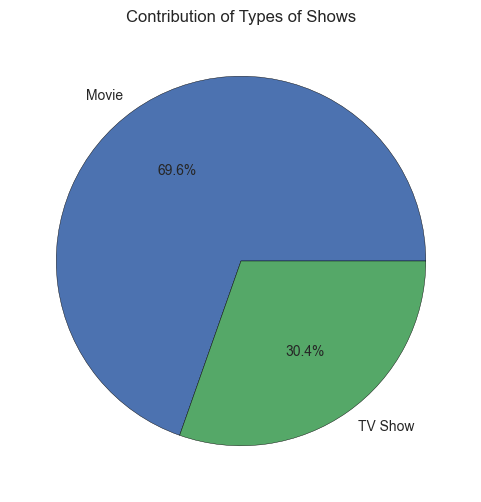

In [27]:
data = df.groupby("type")["type"].count().reset_index(name="count")
plt.figure(figsize=(6, 6))
plt.pie(data["count"], labels=data["type"], autopct="%1.1f%%", wedgeprops={"edgecolor":"black"})
plt.title("Contribution of Types of Shows")

<font style="font-size:15px"><pre>There are nearly <u>70%</u> of production on netflix is <u>Movies</u>
Remaining <u>30%</u> are <u>TV Shows</u></pre></font>

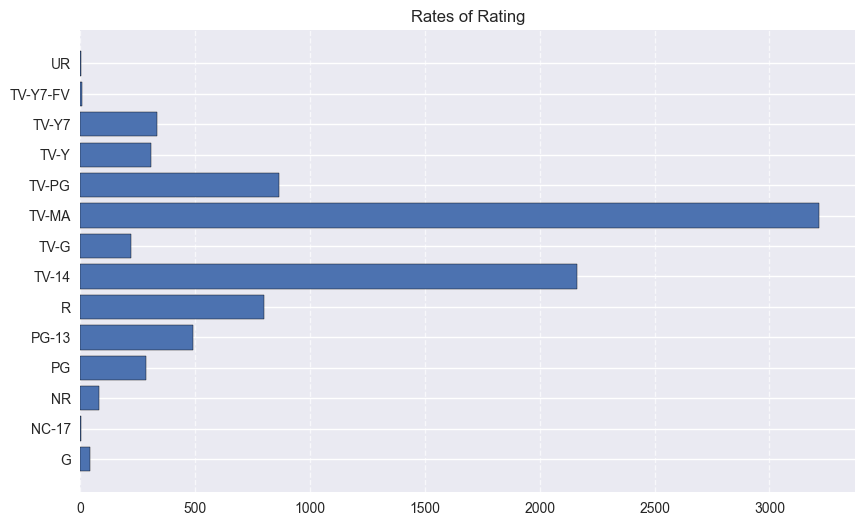

In [28]:
data = df.groupby("rating")["rating"].count().reset_index(name="count")
plt.figure(figsize=(10, 6))
plt.barh(data["rating"], data["count"], height=0.8, edgecolor="black")
plt.title("Rates of Rating")
plt.grid(alpha=0.7, ls="--", axis="x")

<font style="font-size:15px"><pre>Most of the Movies/TV Shows are <u>TV-MA, TV-14, TV-PG, R, PG-13</u> rated</pre></font>

Text(0.5, 1.0, 'Rates of Category')

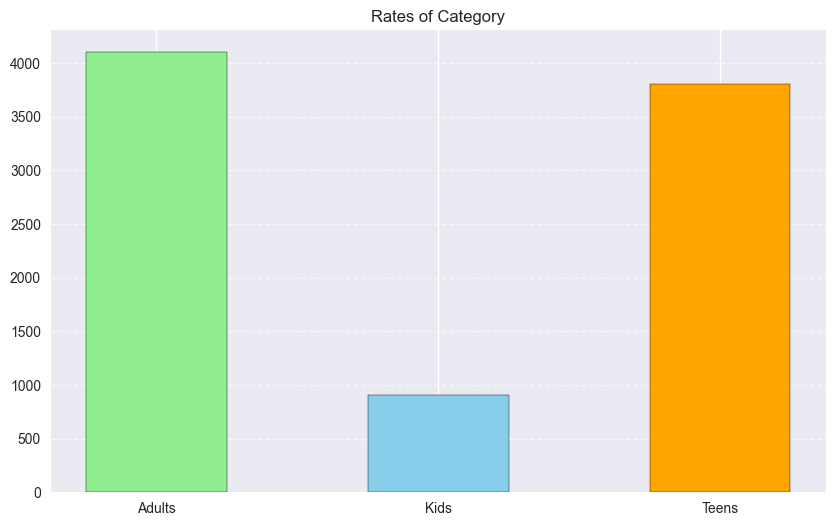

In [29]:
rating_groups = {
    'Kids': ['TV-Y', 'TV-Y7', 'TV-G', 'G', 'TV-Y7-FV'],
    'Teens': ['TV-PG', 'PG', 'PG-13', 'TV-14'],
    'Adults': ['TV-MA', 'R', 'NC-17', 'NR', 'UR']
}
def categorize(rating):
    if rating in rating_groups["Kids"]:
        return "Kids"
    elif rating in rating_groups["Teens"]:
        return "Teens"
    elif rating in rating_groups["Adults"]:
        return "Adults"
    else:
        return "Unknown"

df["category"] = df["rating"].apply(categorize)
data = df.groupby("category")["category"].count().reset_index(name="count")
plt.figure(figsize=(10, 6))
plt.bar(data["category"], data["count"], width=0.5, edgecolor="black", color=["lightgreen", "skyblue", "orange"])
plt.grid(alpha=0.7, axis="y", ls="--")
plt.title("Rates of Category")

<font style="font-size:15px"><pre>There are More <u>Adult and Teen</u> Content compared to <u>Kids</u> Content</pre></font>

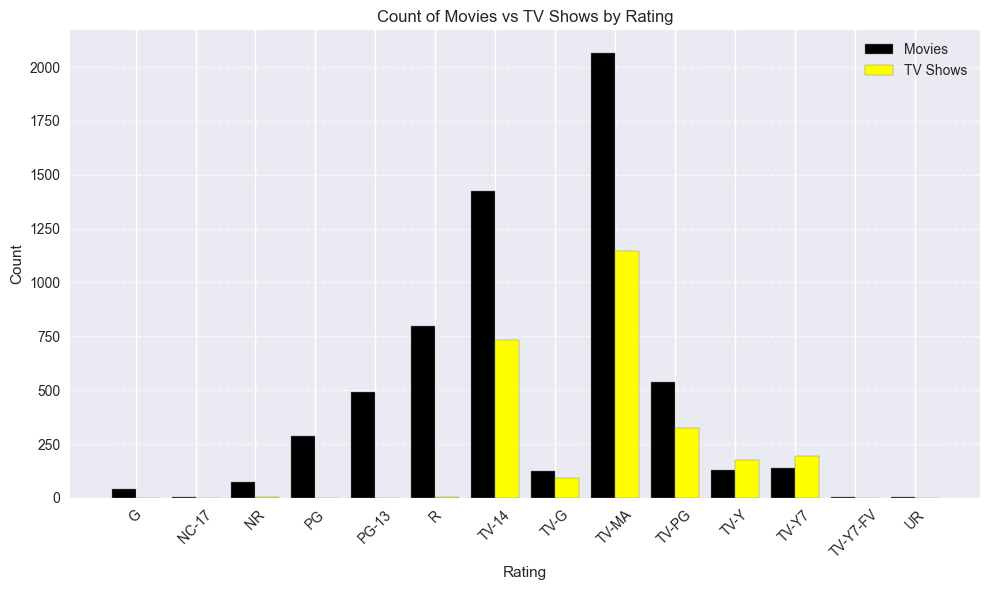

In [30]:
data = df.groupby(["type", "rating"]).size().reset_index(name="count")
pivot = data.pivot(index="rating", columns="type", values="count").fillna(0)
ratings = pivot.index.tolist()
x_pins = np.arange(len(ratings))
w = 0.4
plt.figure(figsize=(10, 6))
plt.bar(x_pins - w/2, pivot.get("Movie", pd.Series(0, index=pivot.index)), width=w, label="Movies", color="black", edgecolor="grey")
plt.bar(x_pins + w/2, pivot.get("TV Show", pd.Series(0, index=pivot.index)), width=w, label="TV Shows", color="yellow", edgecolor="grey")
plt.grid(axis="y", ls="--", alpha=0.7)
plt.xticks(x_pins, ratings, rotation=45)
plt.ylabel("Count")
plt.xlabel("Rating")
plt.title("Count of Movies vs TV Shows by Rating")
plt.legend()
plt.tight_layout()

<font style="font-size:15px"><pre>From this plot we can see that 
<u>TV-MA, TV-14, R</u> are the Top 3 ratings for <u>Movies</u>
<u>TV-MA, TV-14, TV-PG</u> are the Top 3 ratings for <u>TV Shows</u></pre></font>

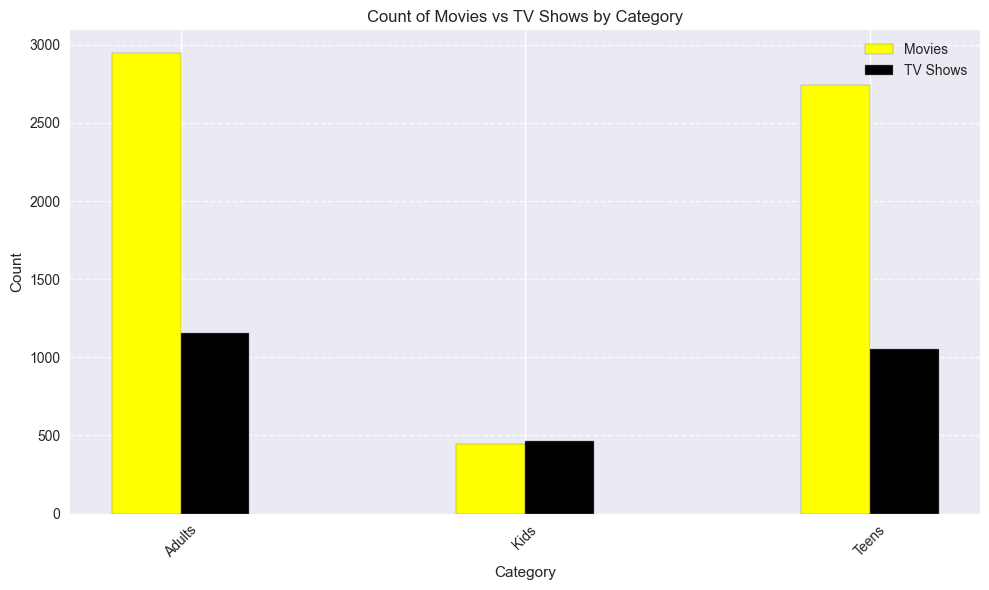

In [31]:
data = df.groupby(["type", "category"]).size().reset_index(name="count")
pivot = data.pivot(index="category", columns="type", values="count").fillna(0)
cat = pivot.index.to_list()
x_pins = np.arange(len(cat))
w = 0.2
plt.figure(figsize=(10, 6))
plt.bar(x_pins - w/2, pivot["Movie"], width=w, color="yellow", edgecolor="grey", label="Movies")
plt.bar(x_pins + w/2, pivot["TV Show"], width=w, color="black", edgecolor="grey", label="TV Shows")
plt.xticks(x_pins, cat, rotation=45)
plt.title("Count of Movies vs TV Shows by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.8, ls="--", axis="y")
plt.tight_layout()

<font style="font-size:15px"><pre>For <u>Adults & Teens</u> there are more number of Movies than TV Shows
For <u>Kids</u> there are more number of TV Shows than Movies</pre></font>

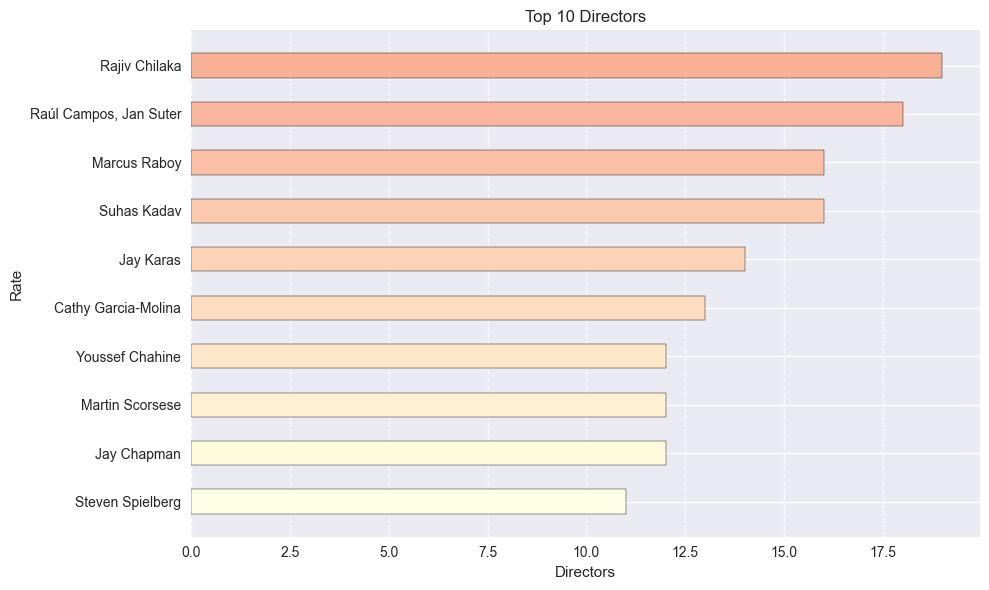

In [32]:
# Top 10 Directors
data = df.groupby("director").size().reset_index(name="count")
data = data.sort_values(by="count", ascending=False)
data = data.iloc[1: 11]
colors = ["#f8b195", "#f9b59d", "#fabfa5", "#fbc9ae", "#fcd3b6", "#fdddc0", "#fee7c9", "#fff1d3", "#fffadb", "#ffffe5"]
plt.figure(figsize=(10, 6))
plt.barh(data["director"], data["count"], height=0.5, edgecolor="black", color=colors)
plt.gca().invert_yaxis()
plt.title("Top 10 Directors")
plt.xlabel("Directors")
plt.ylabel("Rate")
plt.grid(alpha=0.8, ls="--", axis="x")
plt.tight_layout()

<font style="font-size:15px"><pre>Here are the <u>Top 10 Directors</u> with highest number of films</pre></font>

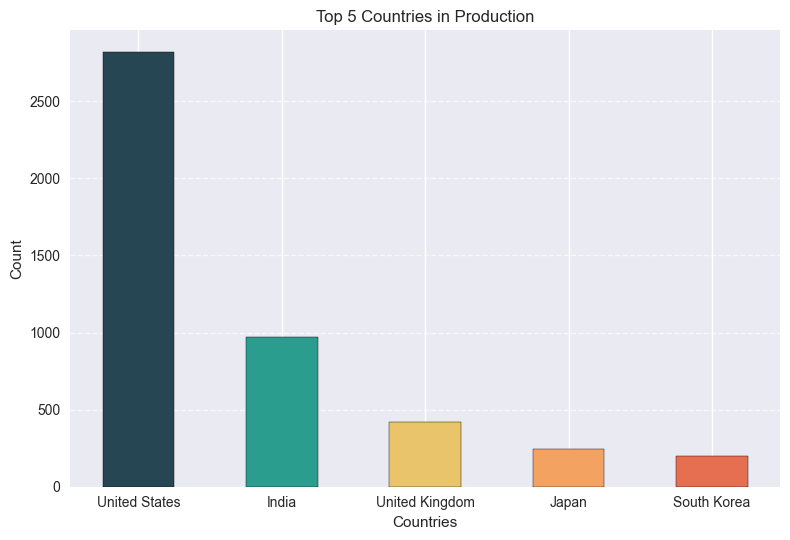

In [33]:
# Top 5 countries with large production
data = df.groupby("country")["country"].count().reset_index(name="count").sort_values(by="count", ascending=False)
data = data[data["country"]!="Unknown"]
data = data.iloc[:5]
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
plt.bar(data["country"], data["count"], width=0.5, edgecolor="black", color=colors)
plt.title("Top 5 Countries in Production")
plt.xlabel("Countries")
plt.ylabel("Count")
plt.grid(alpha=0.7, ls="--", axis="y")
plt.tight_layout()

<font style="font-size:15px"><pre>In the above plot we can see the top 5 countries that are involved in Production.
Also in them <u>United States</u> is on Top with <u>2500+</u> productions</pre></font>

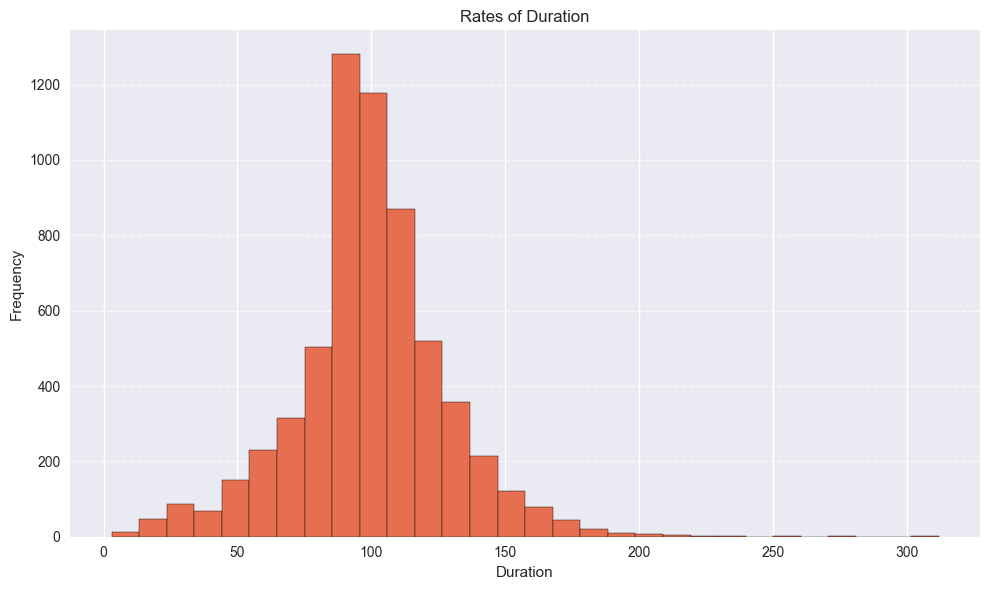

In [34]:
# Rates of Duration
data = df[df["duration"].str.contains("min")]["duration"].str.replace(" min", "").astype(int)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, color="#e76f51", edgecolor="black")
plt.title("Rates of Duration")
plt.ylabel("Frequency")
plt.xlabel("Duration")
plt.grid(alpha=0.7, ls="--", axis="y")
plt.tight_layout()

<font style="font-size:15px"><pre>Around <u>4000+ Movies</u> are having <u>70 - 130 Mins</u> of Duration</pre></font>

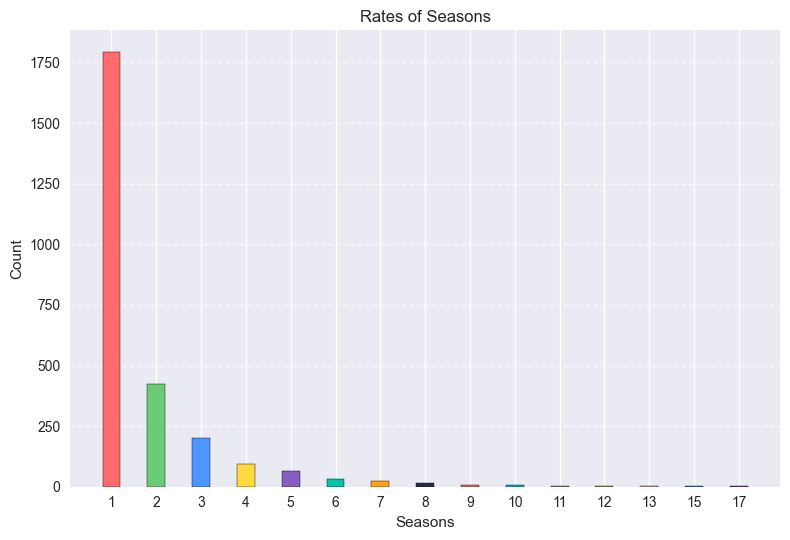

In [35]:
# Rates of seasons
data = df[df["duration"].str.contains("Season")]["duration"].str.replace(" Seasons", "")
data = pd.DataFrame(data.str.replace(" Season", "").astype(int))
data = data.groupby("duration")["duration"].count().reset_index(name="count")
colors = ["#FF6B6B", "#6BCB77", "#4D96FF", "#FFD93D", "#845EC2", "#00C2A8", "#FF9F1C", "#2B2D42", "#E76F51", "#06AED5", "#F67280", "#8AC926", "#FFB4A2", "#3A86FF", "#8338EC", "#2EC4B6", "#B5838D"]
x_pins = np.arange(len(data["duration"]))
plt.bar(x_pins, data["count"], width=0.4, edgecolor="black", color=colors)
plt.xticks(x_pins, data["duration"])
plt.title("Rates of Seasons")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.grid(alpha=0.8, axis="y", ls="--")
plt.tight_layout()

<font style="font-size:15px"><pre>The most of the Shows on Netflix had Only <u>One Season</u> with <u>1750+ Shows</u></pre></font>

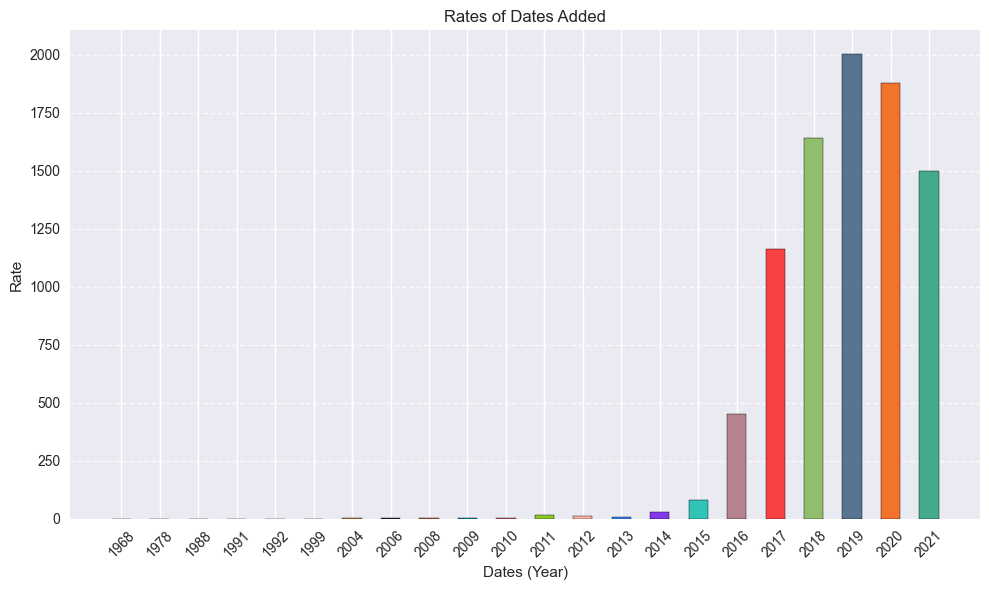

In [36]:
# Rates of Dates Added
data = pd.DataFrame(df["date_added"].dt.year)
data = data.groupby("date_added")["date_added"].count().reset_index(name="count")
colors = ["#FF6B6B", "#6BCB77", "#4D96FF", "#FFD93D", "#845EC2", "#00C2A8", "#FF9F1C", "#2B2D42", "#E76F51", "#06AED5", "#F67280", "#8AC926", "#FFB4A2", "#3A86FF", "#8338EC", "#2EC4B6", "#B5838D", "#F94144", "#90BE6D", "#577590", "#F3722C", "#43AA8B"]
x_pins = np.arange(len(data["date_added"]))
plt.figure(figsize=(10, 6))
plt.bar(x_pins, data["count"], width=0.5, edgecolor="black", color=colors)
plt.xticks(x_pins, data["date_added"], rotation=45)
plt.title("Rates of Dates Added")
plt.xlabel("Dates (Year)")
plt.ylabel("Rate")
plt.grid(axis="y", alpha=0.8, ls="--")
plt.tight_layout()
plt.show()

<font style="font-size:15px"><pre>The most of the production is done between <u>2016 - 2021</u></pre></font>

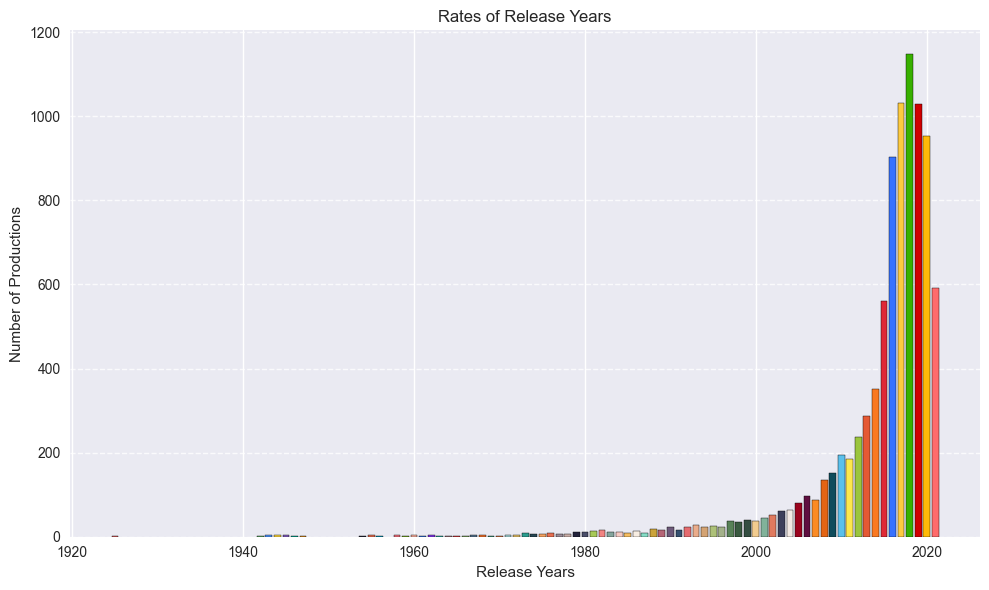

In [37]:
data = df.groupby("release_year")["release_year"].count().reset_index(name="rate")
colors = ["#FF6B6B", "#6BCB77", "#4D96FF", "#FFD93D", "#845EC2", "#00C2A8", "#FF9F1C", "#2B2D42", "#E76F51", "#06AED5", "#F67280", "#8AC926", "#FFB4A2", "#3A86FF", "#8338EC", "#2EC4B6", "#B5838D", "#F94144", "#90BE6D", "#577590", "#F3722C", "#43AA8B", "#F9844A", "#A8DADC", "#E9C46A", "#2A9D8F", "#264653", "#F4A261", "#E76F51", "#9A8C98", "#C9ADA7", "#22223B", "#4A4E69", "#A7C957", "#F28482", "#84A59D", "#F5CAC3", "#F6BD60", "#F7EDE2", "#84DCC6", "#CCA43B", "#B56576", "#6D597A", "#355070", "#E56B6F", "#EAAC8B", "#D4A373", "#ADC178", "#A3B18A", "#588157", "#3A5A40", "#344E41", "#F2CC8F", "#81B29A", "#E07A5F", "#3D405B", "#F2E9E4", "#9A031E", "#5F0F40", "#FB8B24", "#E36414", "#0F4C5C", "#5BC0EB", "#FDE74C", "#9BC53D", "#E55934", "#FA7921", "#DF2935", "#3772FF", "#FDCA40", "#38B000", "#D00000", "#FFBA08"]
plt.figure(figsize=(10, 6))
plt.bar(data["release_year"], data["rate"], edgecolor="black", color=colors)
plt.title("Rates of Release Years")
plt.xlabel("Release Years")
plt.ylabel("Number of Productions")
plt.grid(alpha=0.8, ls="--", axis="y")
plt.tight_layout()

<font style="font-size:15px"><pre>This plot tells us <u>Most of the Releases</u> are Done in between <u>2000 - 2020</u></pre></font>

## Conclusions

- ~70% of the titles are Movies and ~30% are TV Shows.
- Most common content ratings are TV-MA and TV-14 (adult-oriented content dominates).
- The dataset contains inconsistent/missing values in `rating`, `duration`, and `date_added` which were cleaned.
- Netflix expanded strongly after 2015 (if you visualized additions by year).
- Genres related to International content and Dramas appear most frequently.
